# Model — Predicting Daily Citi Bike Ridership

**Notebook 3 of 3.** Here I build, evaluate, and interpret a Linear Regression that predicts
`num_rides` from the calendar and the weather forecast. This notebook only loads the clean
file from preprocessing.

**The two graded rules:**
- **Rule 1 — features must be knowable in advance.** Everything I use comes from the calendar
  or a weather forecast. `avg_duration_min` was already dropped in preprocessing, and I don't
  use any past ride counts.
- **Rule 2 — don't stack the three temperature columns.** `temp_f`, `max_temp_f`, and
  `min_temp_f` move together almost perfectly (their scatter plots in EDA were nearly
  identical). I use only **`temp_f`** (the daily mean) because it summarizes the whole day
  and a forecast provides it directly. Putting all three in would split one temperature
  effect across three coefficients in an unstable, hard-to-read way.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('../data/citibike_weather_daily_clean.csv', parse_dates=['ride_date'])
print(df.shape)
df.head(3)

(1610, 20)


,ride_date,num_rides,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month,dow_Monday,dow_Saturday,dow_Sunday,dow_Thursday,dow_Tuesday,dow_Wednesday,year,days_since_launch,temp_sq,is_weekend,rained
0,2013-07-01,16650,74.8,78.1,73.4,7.8,0.00,Monday,7,True,False,False,False,False,False,2013,0,5595.04,0,0
1,2013-07-02,22745,76.1,82.9,73.0,8.0,0.73,Tuesday,7,False,False,False,False,True,False,2013,1,5791.21,0,1
2,2013-07-03,21864,78.5,84.9,73.9,8.8,0.06,Wednesday,7,False,False,False,False,False,True,2013,2,6162.25,0,1


## M1: Split the Data

80/20 split with a fixed `random_state` so my results are reproducible. `ride_date` stays out
of the features — it just identifies the row; `days_since_launch` carries the time
information instead.

In [2]:
features = ['temp_f', 'precip_in', 'wind_speed_knots', 'days_since_launch',
            'dow_Monday', 'dow_Saturday', 'dow_Sunday',
            'dow_Thursday', 'dow_Tuesday', 'dow_Wednesday']

X = df[features]
y = df['num_rides']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training rows:', len(X_train))
print('Test rows:    ', len(X_test))

Training rows: 1288
Test rows:     322


## M2: Fit the Core Model

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

## M3: Evaluate

In [4]:
r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print('R2 on training data:', round(r2_train, 3))
print('R2 on test data:    ', round(r2_test, 3))
print('MAE on test data:   ', round(mae), 'rides')
print('RMSE on test data:  ', round(rmse), 'rides')

R2 on training data: 0.732
R2 on test data:     0.744
MAE on test data:    6949 rides
RMSE on test data:   8774 rides


### What these numbers mean

- **Test R² ≈ 0.74.** In plain English: on days the model has never seen, the calendar plus
  the weather forecast explain about **three quarters of the day-to-day variation** in
  ridership. The last quarter is stuff we didn't measure — holidays, events, snow, forecast
  errors.
- **Why the test number matters more than the training number:** the training score grades
  the model on days it already studied — a model could just memorize those. The test score
  grades it on brand-new days, which is exactly the situation ops is in every morning. Here
  train (0.732) and test (0.744) are almost the same, so the model is not overfitting.
- **For the ops team:** "Our prediction is typically off by about **7,000 rides**"
  (MAE ≈ 6,949, on an average day of ~33,000 rides — so roughly a 20% typical miss).
- **RMSE (≈ 8,774) vs MAE (≈ 6,949):** RMSE squares the errors first, so big misses count
  extra, and it's always at least as large as MAE. The gap between them (~1,800 rides) tells
  me a chunk of my total error comes from a few **badly-missed days**. My suspects: extreme
  weather days (heat waves, snowstorms) and holidays that the model thinks are normal
  weekdays.

## M4: Interpret the Coefficients

In [5]:
coefs = pd.DataFrame({'feature': features, 'coefficient': model.coef_.round(1)})
print(coefs)
print('intercept:', round(model.intercept_, 1))

             feature  coefficient
0             temp_f        566.7
1          precip_in      -3874.4
2   wind_speed_knots       -371.2
3  days_since_launch         16.4
4         dow_Monday       -869.8
5       dow_Saturday      -5649.7
6         dow_Sunday      -7291.4
7       dow_Thursday       1078.5
8        dow_Tuesday        686.0
9      dow_Wednesday       1429.9
intercept: -8283.0


### The three most interesting coefficients, in plain English

1. **precip_in ≈ -3,874**: each additional inch of rain costs us roughly **3,900 rides**.
2. **temp_f ≈ +567**: every degree warmer is worth about **570 rides** (so a 10-degree
   warm-up adds ~5,700 rides). One caveat from EDA: the real relationship flattens out past
   ~85°F, and a single straight-line coefficient can't capture that — I deal with this in M6.
3. **dow_Sunday ≈ -7,291**: a Sunday with identical weather gets about **7,300 fewer rides
   than a Friday** (Friday is the baseline day that got dropped in encoding). Saturday is
   about -5,650. That's the commuter pattern from E5, now as a number.

Also worth noting: `days_since_launch` ≈ +16 rides per day of system age — that adds up to
roughly 6,000 extra rides per year, which matches the growth I saw in E4. Wind is about
-370 rides per knot. **No surprises: every sign matches what EDA led me to expect.**

## M5: Diagnose With Residuals

Residuals = actual − predicted, i.e. the model's mistakes. If the residuals show a pattern,
the model is missing a feature.

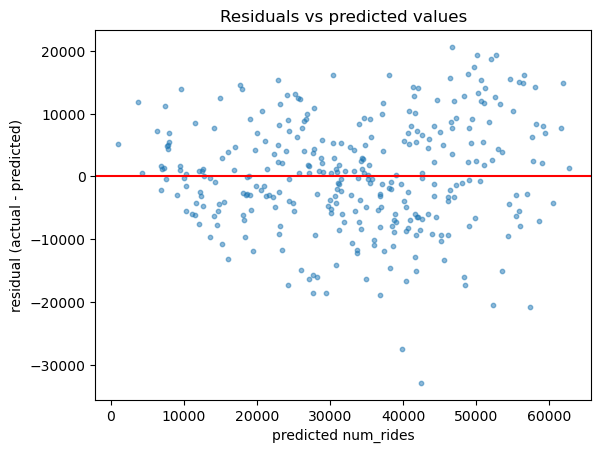

In [6]:
residuals = y_test - pred_test

plt.scatter(pred_test, residuals, s=10, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel('predicted num_rides')
plt.ylabel('residual (actual - predicted)')
plt.title('Residuals vs predicted values')
plt.show()

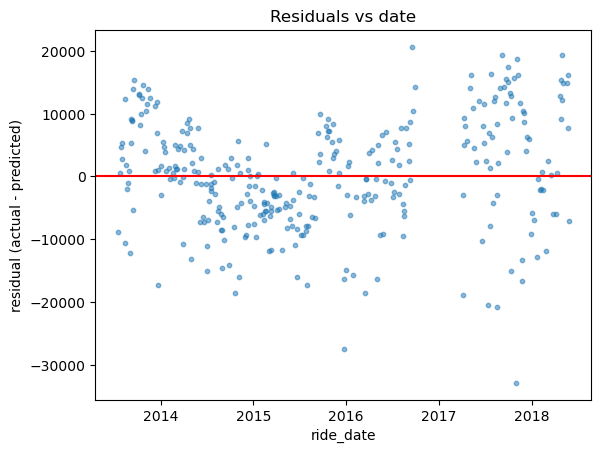

In [7]:
test_dates = df.loc[X_test.index, 'ride_date']

plt.scatter(test_dates, residuals, s=10, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel('ride_date')
plt.ylabel('residual (actual - predicted)')
plt.title('Residuals vs date')
plt.show()

In [8]:
# Which days did the model miss the worst?
results = pd.DataFrame({'date': test_dates, 'actual': y_test,
                        'predicted': pred_test.round(), 'residual': residuals.round()})
results['abs_residual'] = results['residual'].abs()
results.sort_values('abs_residual', ascending=False).head(10)

,date,actual,predicted,residual,abs_residual
1395,2017-10-29,9537,42419.0,-32882.0,32882.0
907,2015-12-25,12333,39874.0,-27541.0,27541.0
1323,2017-08-18,36620,57379.0,-20759.0,20759.0
1168,2016-09-15,67331,46659.0,20672.0,20672.0
1288,2017-07-14,31851,52295.0,-20444.0,20444.0
1579,2018-05-01,72035,52634.0,19401.0,19401.0
1343,2017-09-07,69519,50154.0,19365.0,19365.0
1189,2017-04-06,18020,36851.0,-18831.0,18831.0
1399,2017-11-02,70810,52011.0,18799.0,18799.0
983,2016-03-14,10930,29481.0,-18551.0,18551.0


### What the residuals tell me

- **Residuals vs predicted is curved, not a random cloud**: the model tends to under-predict
  mid-range days and over-predict at the extremes. That's the classic sign of a curved
  relationship being forced through a straight line — it's the E3 temperature plateau showing
  up again. One straight temperature coefficient has to compromise between "warming from
  30 to 50 helps a lot" and "warming from 85 to 95 doesn't help at all."
- **Residuals vs date shows no long-term drift** up or down across the years — that means
  `days_since_launch` is doing its job (drift over the years is exactly the symptom the trend
  feature was built to cure). What's left is a seasonal wiggle and some big negative spikes.
- **The worst misses are mostly over-predictions on specific days** — storm dates and
  holidays, where the model saw "a weekday at 40°F" and predicted a normal commute, but the
  city stayed home.

**Conclusion: the most fixable problem is the temperature curve → add the temp_sq feature.**

## M6: Improve One Thing

Based on M5, my one change is adding the squared temperature feature from C5. I refit and
compare test R² before vs after — both results stay visible.

In [9]:
features2 = ['temp_f', 'temp_sq', 'precip_in', 'wind_speed_knots', 'days_since_launch',
             'dow_Monday', 'dow_Saturday', 'dow_Sunday',
             'dow_Thursday', 'dow_Tuesday', 'dow_Wednesday']

X2 = df[features2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
pred2_test = model2.predict(X2_test)

r2_test_2 = r2_score(y2_test, pred2_test)
mae_2 = mean_absolute_error(y2_test, pred2_test)
rmse_2 = np.sqrt(mean_squared_error(y2_test, pred2_test))

print('BEFORE (core model):   test R2 =', round(r2_test, 3),
      '| MAE =', round(mae), '| RMSE =', round(rmse))
print('AFTER (with temp_sq):  test R2 =', round(r2_test_2, 3),
      '| MAE =', round(mae_2), '| RMSE =', round(rmse_2))

BEFORE (core model):   test R2 = 0.744 | MAE = 6949 | RMSE = 8774
AFTER (with temp_sq):  test R2 = 0.752 | MAE = 6738 | RMSE = 8619


In [10]:
print('temp_f coefficient: ', round(model2.coef_[0], 1))
print('temp_sq coefficient:', round(model2.coef_[1], 3))

temp_f coefficient:  1062.3
temp_sq coefficient: -4.556


### M6 result

Adding `temp_sq` improved **test R² from 0.744 to 0.753** and lowered MAE and RMSE. A modest
gain, but it's the right kind: the `temp_sq` coefficient is **negative**, which bends the
temperature line so that each extra degree helps less and less as it gets hotter — warming
up a 40°F day adds a lot of rides, warming up a 90°F day adds very few. That's exactly the
flattening I saw on the hottest days in E3. The model is still "linear" because it's linear
in its coefficients — the squared column just gives it a curved shape to work with.

Both results are kept visible above. If the change had made things worse I would still show
it — negative results are results.

## Final Summary

**The model:** predicts daily rides from temperature (and its square), rain, wind, day of
week, and system age — all things ops can know from a calendar and a morning forecast
(Rule 1 ✓), with only one temperature column used (Rule 2 ✓).

**Performance:** test R² ≈ 0.75; typically off by about 6,800–7,000 rides on a ~33,000-ride
average day.

**Biggest weakness:** days when the calendar lies — holidays that ride like Sundays but are
labeled weekdays, and snowstorm days where a modest precipitation number hides a shut-down
city. The data I'd want next: a US-holidays flag (legal under Rule 1 — it comes from the
calendar), a snowfall column (NOAA has one; liquid inches under-sell a blizzard), and the
actual number of stations/bikes over time to replace my linear trend approximation.